In [356]:
import matplotlib
matplotlib.rcParams['font.serif'] = ['Times'] + matplotlib.rcParams['font.serif']
matplotlib.rcParams['font.size'] = 6
matplotlib.rcParams['text.usetex'] = False
matplotlib.rcParams["ps.usedistiller"] = 'xpdf'
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.weight'] = 'normal'
matplotlib.rcParams["mathtext.fontset"] = 'cm'

In [695]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

import random
import math

import pandas as pd

import copy

import cvxpy
cp = cvxpy

import figurefirst as fifi

from braid_analysis import braid_analysis_plots
from braid_analysis import flymath
import fly_plot_lib.plot as fpl

import pynumdiff

import scipy.stats

In [696]:
import sys
sys.path.append('../notebooks')
from splitflow import unifying_algo_analysis_helper as uaah

In [697]:
course_markersize = 2
linear_model_markersize = 3
affine_model_markersize = 3

In [698]:
WEIGHTED_SUM = True

In [699]:
dt = 0.01
interp_t = np.arange(5, 10, dt) 
t = interp_t - interp_t[0]

# load unsteady wind
unsteady_wind = pd.read_hdf('../../../../Data/Fig1_Input_Data/misc/unsteady_timeseries.hdf')
cfd_t = unsteady_wind.Time.values
cfd_xvel = unsteady_wind.xvel.values
cfd_yvel = unsteady_wind.yvel.values
interp_cfd_xvel = np.interp(interp_t, cfd_t, cfd_xvel)
interp_cfd_yvel = np.interp(interp_t, cfd_t, cfd_yvel)
interp_cfd_xvel_smooth, _ = pynumdiff.savgoldiff(interp_cfd_xvel, dt, [3, 31, 31])
interp_cfd_yvel_smooth, _ = pynumdiff.savgoldiff(interp_cfd_yvel, dt, [3, 31, 31])
cfd_wind_direction = np.arctan2(interp_cfd_yvel_smooth, interp_cfd_xvel_smooth)

# generate laminar wind
lam_xvel = -0.4 + np.random.normal(0, 0.05, len(t))
lam_yvel = 0 + np.random.normal(0, 0.05, len(t))
lam_xvel_smooth, _ = pynumdiff.savgoldiff(lam_xvel, dt, [3, 31, 31])
lam_yvel_smooth, _ = pynumdiff.savgoldiff(lam_yvel, dt, [3, 31, 31])
lam_wind_direction = np.arctan2(lam_yvel_smooth, lam_xvel_smooth)
lam_wind_speed = (lam_xvel_smooth**2 + lam_yvel_smooth**2)**0.5

# generate still air
still_xvel = -0 + np.random.normal(0, 0.01, len(t))
still_yvel = 0 + np.random.normal(0, 0.01, len(t))
still_xvel_smooth, _ = pynumdiff.savgoldiff(still_xvel, dt, [3, 31, 31])
still_yvel_smooth, _ = pynumdiff.savgoldiff(still_yvel, dt, [3, 31, 31])
still_wind_direction = np.arctan2(still_yvel_smooth, still_xvel_smooth)
still_wind_speed = (still_xvel_smooth**2 + still_yvel_smooth**2)**0.5

In [700]:

smooth_circle_course = 3.95*t
raw_circle_course = uaah.wrap_angle(smooth_circle_course)

In [743]:
scenario = 'stillair'

if scenario == 'laminar':
    cfd_wind_speed = lam_wind_speed
    wind_direction = lam_wind_direction
    rotation = uaah.wrap_angle( wind_direction + np.pi/2. )
    
    axis_ratio = 0.1
    color = '#991128ff'

if scenario == 'unsteady':
    cfd_wind_speed = (interp_cfd_xvel_smooth**2 + interp_cfd_yvel_smooth**2)**0.5
    wind_direction = cfd_wind_direction
    rotation = uaah.wrap_angle( wind_direction + np.pi/2. )
    
    axis_ratio = 0.3
    color = '#2b75b3b3'

if scenario == 'stillair':
    cfd_wind_speed = still_wind_speed
    wind_direction = still_wind_direction
    rotation = uaah.wrap_angle( wind_direction + np.pi/2 )
    
    axis_ratio = 0.8
    color = '#084a72ff'

In [744]:
FIGURE_NAME = 'unifying_math.svg'

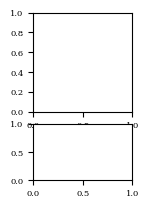

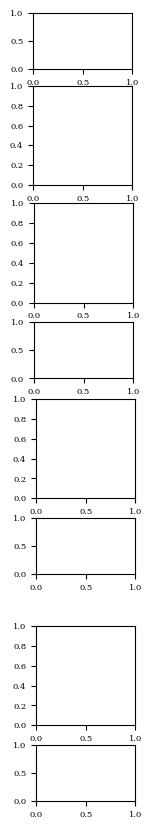

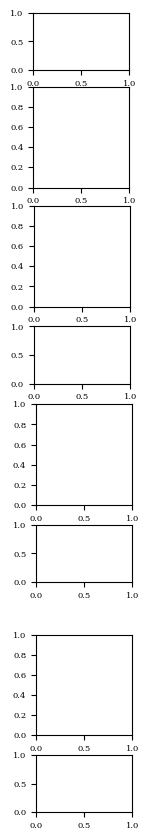

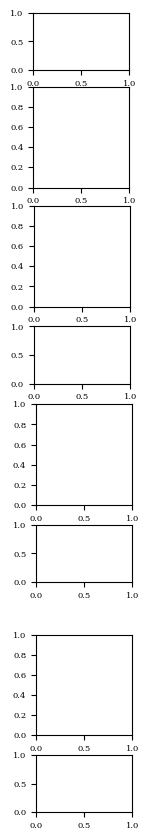

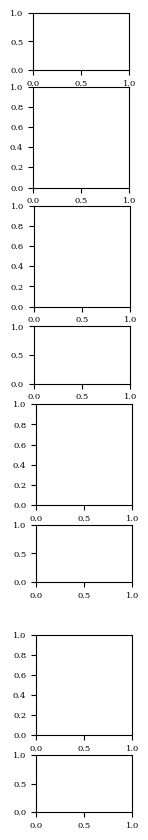

In [745]:
layout = fifi.svg_to_axes.FigureLayout(FIGURE_NAME, autogenlayers=True, make_mplfigures=True, hide_layers=[], dpi=600)


In [746]:
ax = layout.axes[(scenario, 'wind')]

#####################################################################################################
# Wind

ax.scatter(t, wind_direction, s=2, c=cfd_wind_speed, cmap='plasma', vmin=0, vmax=0.6)

ax.set_ylim(-np.pi, np.pi)

(-3.141592653589793, 3.141592653589793)

In [747]:
def construct_affine_transform(rotation_angle, major_axis, minor_axis):
    """
    rotation_angle: in radians
    major_axis, minor_axis: scaling factors
    """
    # Rotation matrix
    c, s = np.cos(rotation_angle), np.sin(rotation_angle)
    R = np.array([[c, -s], [s, c]])
    
    # Scaling matrix
    S = np.array([[major_axis, 0], [0, minor_axis]])
    
    # Linear transformation
    A = R @ S @ R.T
    
    # Translation (adjust as needed)
    b = np.array([0, 0])  # or compute based on desired center
    
    return A

In [748]:
ax = layout.axes[(scenario, 'ellipse')]

#####################################################################################################
# Goal A

# raw circle
raw_circle_x = np.cos(raw_circle_course)
raw_circle_y = np.sin(raw_circle_course)
raw_circle_xy = np.vstack([raw_circle_x, raw_circle_y])

raw_course_angle = np.arctan2(raw_circle_xy[1,:], raw_circle_xy[0,:])

# plot raw circle
ax.plot(raw_circle_x, raw_circle_y, '--', color='black', linewidth=0.5)

#####################################################################################################
# Goal B

major_axis = 1
minor_axis = major_axis*axis_ratio
v_matrix = np.eye(2)

#AMs = [uaah.reconstruct_affine(r, major_axis, minor_axis, v_matrix, translation=None) for r in rotation]
AMs = [construct_affine_transform(r, major_axis, minor_axis) for r in rotation]
affine_warped_circle_xy = np.hstack([AMs[i]@raw_circle_xy[:,i:i+1] for i in range(len(AMs))])
affine_warped_course_angle = np.arctan2(affine_warped_circle_xy[1,:], affine_warped_circle_xy[0,:])

ax.plot(affine_warped_circle_xy[0,:], affine_warped_circle_xy[1,:], color=color, linewidth=0.5)



# mean
mean_rotation = uaah.mean_angle(rotation)
major_axis = 1
minor_axis = major_axis*axis_ratio
v_matrix = np.eye(2)
AM = uaah.reconstruct_affine(mean_rotation, major_axis, minor_axis, v_matrix, translation=None)
mean_affine_warped_circle_xy = AM@raw_circle_xy
ax.plot(mean_affine_warped_circle_xy[0,:], mean_affine_warped_circle_xy[1,:], color=color, linewidth=2)


if WEIGHTED_SUM:

    if scenario == 'stillair':
        alpha = 0.1
    elif scenario == 'unsteady':
        alpha = .9
    elif scenario == 'laminar':
        alpha = 1

    tmp = raw_circle_xy*(1-alpha) + affine_warped_circle_xy*alpha

    affine_warped_course_angle = np.arctan2(tmp[1,:], tmp[0,:])
    affine_warped_circle_xy = np.vstack((np.cos(affine_warped_course_angle), np.sin(affine_warped_course_angle)))


ax.set_aspect('equal')


In [749]:
ax = layout.axes[(scenario, 'trajec3')]

speed = 0.3
velx = speed*np.cos(affine_warped_course_angle)
vely = speed*np.sin(affine_warped_course_angle)

x = np.cumsum(velx)*dt
y = np.cumsum(vely)*dt

ax.set_aspect('equal')
braid_analysis_plots.plot_arrowhead_trajectory(x, y, color='black', linewidth=1, ax=ax, arrow_length=0.06)



In [750]:
#####################################################################################################
# Goal C
if 1:
    ax = layout.axes[(scenario, 'trajec1')]
else:
    fig = plt.figure()
    ax = fig.add_subplot(111)

#######################

upwind_direction = uaah.wrap_angle(wind_direction+np.pi)


# option A: penalize turning through downwind if there is wind
gamma = 0.08*(1-axis_ratio)**2
course_cvx = cvxpy.Variable(len(affine_warped_course_angle))
pis = cvxpy.Variable(len(affine_warped_course_angle), integer=True)

eq = course_cvx - affine_warped_course_angle + pis*2*np.pi
L1 = cvxpy.sum(cvxpy.huber(eq, M=0.1))
L2 = cvxpy.tv((course_cvx))
L3 = cvxpy.sum_squares(course_cvx-upwind_direction)

objective = cvxpy.Minimize(L1 + 
                           0*L2 +
                           gamma*L3 
                           )

constraints = [
  pis >= -10, pis <= 10,  # Adjust based on your data
]

problem = cvxpy.Problem(objective, constraints)

problem.solve(solver=cvxpy.GUROBI,
            Threads=8,              # Use multiple cores
            Method=2,               # Try different algorithms: -1=auto, 0=primal, 1=dual, 2=barrier
            Presolve=2,             # Aggressive presolve
            FeasibilityTol=1e-5,    # Relax from 1e-6
            OptimalityTol=1e-5,     # Relax from 1e-6
            TimeLimit=20,          # Stop after 5 minutes
            MIPGap=0.01,            # For MIP: accept 1% gap (if applicable)
            )


unwrapped_course_cvx = flymath.unwrap_angle(course_cvx.value, correction_window_for_2pi=40)
cvx_warped_course_angle = uaah.wrap_angle(pynumdiff.savgoldiff(unwrapped_course_cvx, dt, [3,40,40])[0])

cvx_warped_circle_xy = np.vstack([np.cos(cvx_warped_course_angle), np.sin(cvx_warped_course_angle)])


speed = 0.3
velx = speed*np.cos(cvx_warped_course_angle)
vely = speed*np.sin(cvx_warped_course_angle)

x = np.cumsum(velx)*dt
y = np.cumsum(vely)*dt

ax.set_aspect('equal')
braid_analysis_plots.plot_arrowhead_trajectory(x, y, color='black', linewidth=1, ax=ax, arrow_length=0.06)

In [751]:
#####################################################################################################
# Course

ax = layout.axes[(scenario, 'course1')]

ax.plot(t, cvx_warped_course_angle, '.', label='raw data', color='black', markersize=course_markersize, markeredgecolor='none')
ax.plot(t, raw_circle_course, '.', label='line fit', color='blue', markersize=linear_model_markersize, markeredgecolor='none')
ax.plot(t, affine_warped_course_angle, '.', label='line fit', color='magenta', markersize=linear_model_markersize, markeredgecolor='none')

show_labels = False

xticks = [0, 1, 2, 3, 4, 5]
xticklabels = np.array(xticks)

ax.set_xlim(0, 5)
ax.set_xticks(xticks)

if show_labels:
    ax.set_xticklabels(['$0$', '$1$', '$2$', '$3$', '$4$', '$5$'])
else:
    ax.set_xticklabels([])
    
ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_ylim(-np.pi, np.pi)

if show_labels:
    ax.set_yticklabels(['$-\pi$', '','$0$','','$\pi$',])
else:
    ax.set_yticklabels([])
    
fifi.mpl_functions.adjust_spines(ax, ['left', 'bottom'])

if show_labels:
    ax.set_ylabel('Course direction', labelpad=-2)
    ax.set_xlabel('Time (s)')

ax.tick_params(axis='y', pad=2)
ax.tick_params(axis='x', pad=2)

fifi.mpl_functions.adjust_spines(ax, ['left', 'bottom'],
                                 tick_length=2.5,
                                 spine_locations={'left': 5, 'bottom': 5},
                                 linewidth=0.5)
fifi.mpl_functions.set_fontsize(ax, 6)

In [752]:
# upwind
#U = np.atleast_2d(np.array([1,0])).T
U = np.vstack((np.cos(wind_direction+np.pi), np.sin(wind_direction+np.pi)))

In [753]:
if scenario == 'stillair':
    beta = (1-axis_ratio)**2/6
elif scenario == 'unsteady':
    beta = (1-axis_ratio)**2/6
elif scenario == 'laminar':
    beta = (1-axis_ratio)**2/6

# add a little upwind bias
upwind_vector = U
weighted_affine_warped_circle_xy = affine_warped_circle_xy*(1-beta) + upwind_vector*beta

In [754]:
warped_circle_x = weighted_affine_warped_circle_xy[0,:]
warped_circle_y = weighted_affine_warped_circle_xy[1,:]
course_angle = np.arctan2(warped_circle_y, warped_circle_x)

In [755]:
unwrapped_course_angle = flymath.unwrap_angle(course_angle, correction_window_for_2pi=40)

In [756]:
_, unwrapped_course_angle_diff = pynumdiff.savgoldiff(unwrapped_course_angle, dt, [3, 10, 10])

In [757]:
threshold = 8
staircase_approx = [unwrapped_course_angle[0]]
error = 0
for i in range(1, len(unwrapped_course_angle)):
    error += unwrapped_course_angle[i] - staircase_approx[-1]
    if error > threshold:
        staircase_approx.append(unwrapped_course_angle[i] + unwrapped_course_angle_diff[i]*3*dt)
        error = 0
    else:
        staircase_approx.append(staircase_approx[-1])

staircase_warped_course_angle = np.array(staircase_approx)

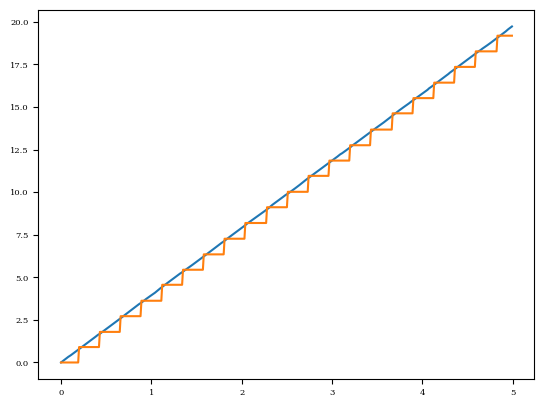

In [758]:
plt.plot(t, unwrapped_course_angle)
plt.plot(t, staircase_approx)

In [759]:
ax = layout.axes[(scenario, 'trajec2')]



staircase_warped_course_x = np.cos(staircase_warped_course_angle)
staircase_warped_course_y = np.sin(staircase_warped_course_angle)

staircase_warped_course_x, _ = pynumdiff.savgoldiff(staircase_warped_course_x, dt, [3, 10, 10])
staircase_warped_course_y, _ = pynumdiff.savgoldiff(staircase_warped_course_y, dt, [3, 10, 10])
staircase_warped_course_angle = np.arctan2(staircase_warped_course_y, staircase_warped_course_x)


speed = 0.3
velx = speed*np.cos(staircase_warped_course_angle)
vely = speed*np.sin(staircase_warped_course_angle)

x = np.cumsum(velx)*dt
y = np.cumsum(vely)*dt

ax.set_aspect('equal')
braid_analysis_plots.plot_arrowhead_trajectory(x, y, color='black', linewidth=1, ax=ax, arrow_length=0.06)

In [760]:
#####################################################################################################
# Course
ax = layout.axes[(scenario, 'course2')]

ax.plot(t, staircase_warped_course_angle, '.', label='raw data', color='black', markersize=course_markersize, markeredgecolor='none')
ax.plot(t, raw_circle_course, '.', label='line fit', color='blue', markersize=linear_model_markersize, markeredgecolor='none')
ax.plot(t, affine_warped_course_angle, '.', label='line fit', color='magenta', markersize=linear_model_markersize, markeredgecolor='none')

show_labels = False

xticks = [0, 1, 2, 3, 4, 5]
xticklabels = np.array(xticks)

ax.set_xlim(0, 5)
ax.set_xticks(xticks)

if show_labels:
    ax.set_xticklabels(['$0$', '$1$', '$2$', '$3$', '$4$', '$5$'])
else:
    ax.set_xticklabels([])
    
ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_ylim(-np.pi, np.pi)

if show_labels:
    ax.set_yticklabels(['$-\pi$', '','$0$','','$\pi$',])
else:
    ax.set_yticklabels([])
    
fifi.mpl_functions.adjust_spines(ax, ['left', 'bottom'])

if show_labels:
    ax.set_ylabel('Course direction', labelpad=-2)
    ax.set_xlabel('Time (s)')

ax.tick_params(axis='y', pad=2)
ax.tick_params(axis='x', pad=2)

fifi.mpl_functions.adjust_spines(ax, ['left', 'bottom'],
                                 tick_length=2.5,
                                 spine_locations={'left': 5, 'bottom': 5},
                                 linewidth=0.5)
fifi.mpl_functions.set_fontsize(ax, 6)

In [761]:
layout.append_figure_to_layer(layout.figures[scenario], scenario, cleartarget=True)
layout.write_svg(FIGURE_NAME)

In [762]:
# layout = fifi.svg_to_axes.FigureLayout(FIGURE_NAME, autogenlayers=True, make_mplfigures=True, hide_layers=[], dpi=600)
# ax = layout.axes[('model', 'ellipse')]
# ax.plot(raw_circle_x, raw_circle_y, '--', color='black', linewidth=0.5)

# ax = layout.axes[('model', 'course')]
# ax.plot(t, raw_circle_course, '.', label='line fit', color='blue', markersize=linear_model_markersize, markeredgecolor='none')

# layout.append_figure_to_layer(layout.figures['model'], 'model', cleartarget=True)
# layout.write_svg(FIGURE_NAME)

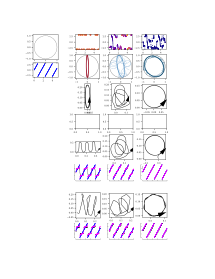

In [763]:
from IPython.display import display,SVG
display(SVG(FIGURE_NAME))